# 시각화 기본과 단변수 그래프

- matplotlib vs seaborn 비교
- 히스토그램 (Histogram)
- 박스플롯 (Box Plot)
- KDE (커널 밀도 추정)
- 라인 플롯 (Line Plot)
- 막대그래프 (Bar Plot) — countplot, barplot
- 파이차트 vs 막대그래프 비교


In [2]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
# Matplotlib 라이브러리 임포트
import matplotlib.pyplot as plt
# Seaborn 라이브러리 임포트
import seaborn as sns

# 한글 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # Prevents minus signs from breaking

print(plt.rcParams['font.family'], plt.rcParams['font.size']) # 폰트확인

# Titanic 데이터셋 로드
titanic = sns.load_dataset('titanic')

['NanumBarunGothic'] 10.0


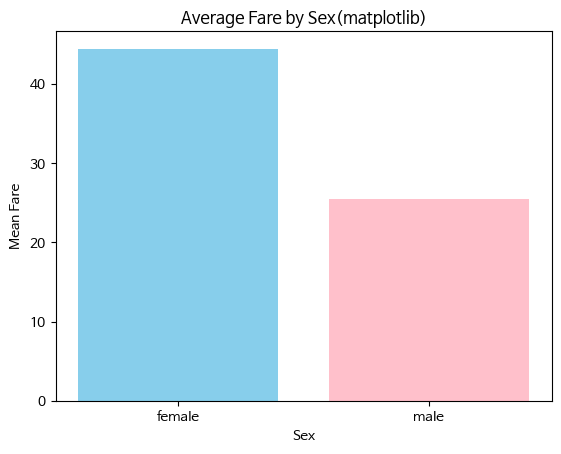

In [4]:
# matplotlib vs seaborn

sex_fare = titanic.groupby("sex")["fare"].mean()

plt.bar(sex_fare.index, sex_fare.values, color=["skyblue", "pink"])
plt.xlabel("Sex")
plt.ylabel("Mean Fare")
plt.title("Average Fare by Sex(matplotlib)")
plt.show()

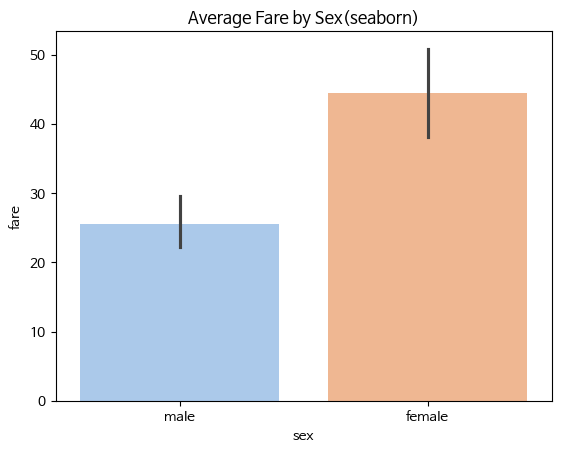

In [6]:
# seaborn
sns.barplot(data=titanic, x="sex", y="fare", palette="pastel")
plt.title("Average Fare by Sex(seaborn)")
plt.show()

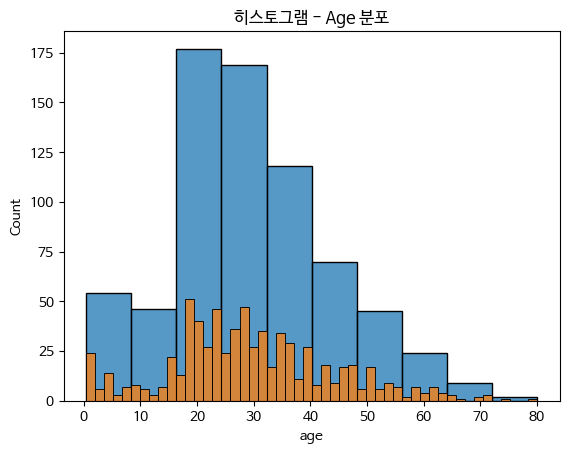

In [8]:
# Histogram
# bins=10
sns.histplot(data=titanic, x="age", bins=10, kde=False, edgecolor="black")
# bins=50
sns.histplot(data=titanic, x="age", bins=50, kde=False, edgecolor="black")
plt.title("히스토그램 - Age 분포")
plt.show()

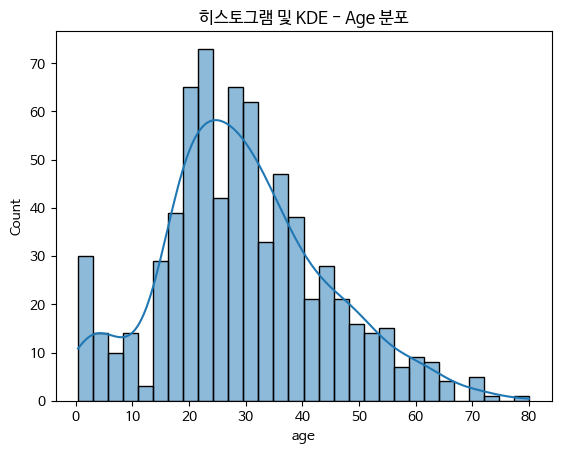

In [9]:
# bins=30
sns.histplot(data=titanic, x="age", bins=30, kde=True, edgecolor="black")
plt.title("히스토그램 및 KDE - Age 분포")
plt.show()

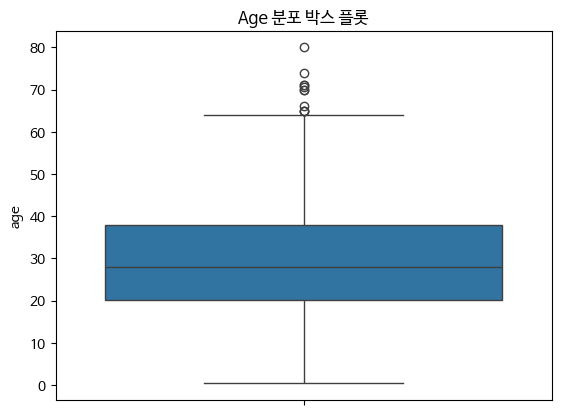

In [10]:
# 박스플롯
sns.boxplot(y=titanic["age"])
plt.title("Age 분포 박스 플롯")
plt.show()

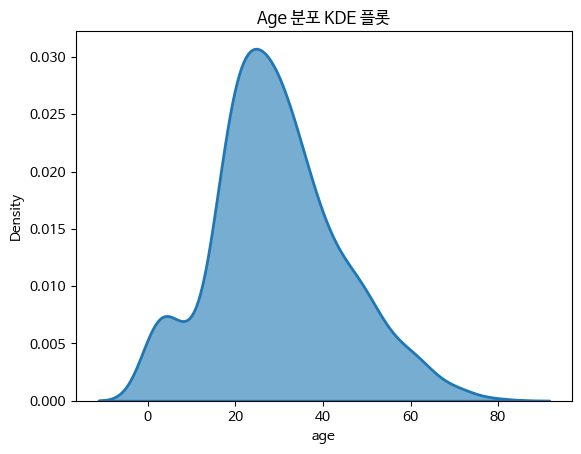

In [11]:
# KDE 플롯

sns.kdeplot(data=titanic, x="age", fill=True, alpha=0.6, linewidth=2)
plt.title("Age 분포 KDE 플롯")
plt.show()

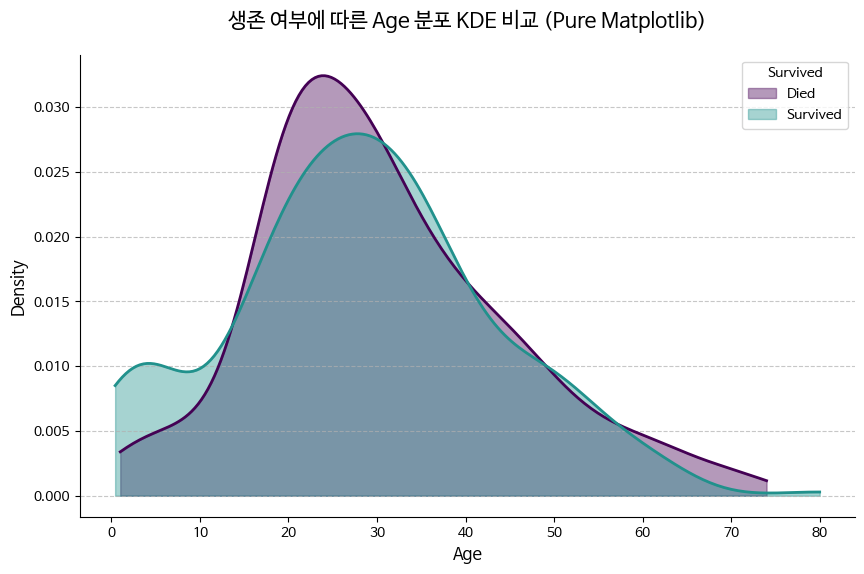

In [12]:
#%% KDE matpkotlib

from scipy.stats import gaussian_kde

# 1. 데이터 준비 및 결측치 제거 (Seaborn은 내부에서 자동 처리)
died_age = titanic[titanic['survived'] == 0]['age'].dropna()
survived_age = titanic[titanic['survived'] == 1]['age'].dropna()

# 2. 도화지 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 3. KDE 계산 및 그리기 로직 (반복문으로 처리)
data_groups = [(died_age, '#440154', 'Died'), (survived_age, '#21918c', 'Survived')]

for data, color, label in data_groups:
    # 수치적인 KDE 곡선 계산
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 200)
    y = kde(x)

    # 선 그리기
    ax.plot(x, y, color=color, linewidth=2)
    # 색상 채우기 (Seaborn의 fill=True와 동일한 역할)
    ax.fill_between(x, y, color=color, alpha=0.4, label=label)

# 4. 세부 디자인 설정 (Matplotlib 문법의 정석)
ax.set_title('생존 여부에 따른 Age 분포 KDE 비교 (Pure Matplotlib)', fontsize=15, pad=20)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Survived')

# 5. 불필요한 상단/우측 테두리 제거 (Seaborn의 despine 효과)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


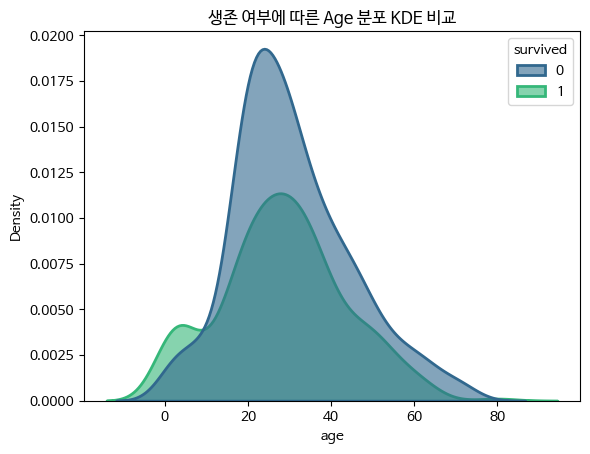

In [14]:
sns.kdeplot(data=titanic, x="age", hue="survived", fill=True, alpha=0.6, linewidth=2,
            palette="viridis", legend=True)
plt.title("생존 여부에 따른 Age 분포 KDE 비교")
plt.show()

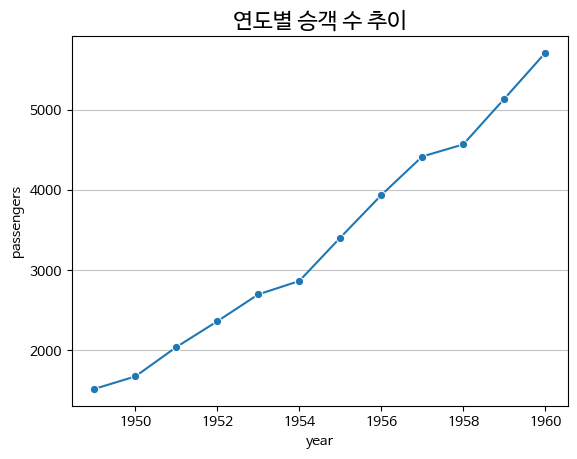

In [16]:
# 라인플롯

# data
flights = sns.load_dataset('flights')
df_yearly_passengers = flights.groupby("year")["passengers"].sum().reset_index()

# 연도별 승객 수 추이 라인 플롯
sns.lineplot(data=df_yearly_passengers, x="year", y="passengers", marker='o')
plt.title("연도별 승객 수 추이", fontsize=16)
plt.grid(axis="y", alpha=0.75)
plt.show()

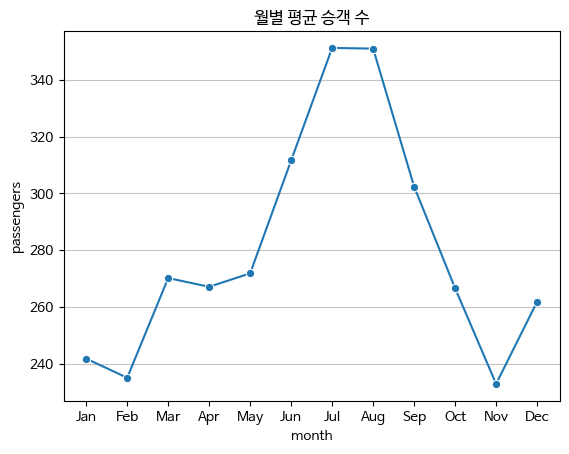

In [17]:
# data
# 월별 평균 승객 수 계산
df_monthly_passengers = flights.groupby('month', observed=False)['passengers'].mean().reset_index()

# 월 순서를 올바르게 정렬하기 위한 코드
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_monthly_passengers['month'] = pd.Categorical(df_monthly_passengers['month'],
                                                categories=month_order, ordered=True)
df_monthly_passengers = df_monthly_passengers.sort_values('month')

sns.lineplot(data=df_monthly_passengers, x="month", y="passengers", marker="o")
plt.title("월별 평균 승객 수")
plt.grid(axis="y", alpha=0.75)
plt.show()

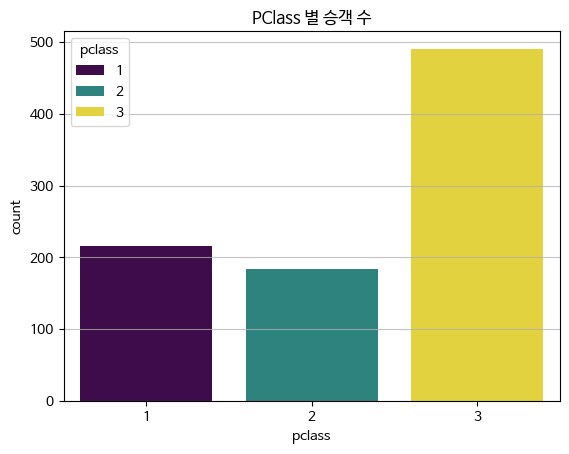

In [19]:
# 막대 그래프
sns.countplot(data=titanic, x="pclass", hue="pclass", palette="viridis")
plt.title("PClass 별 승객 수")
plt.grid(axis="y", alpha=0.75)
plt.show()

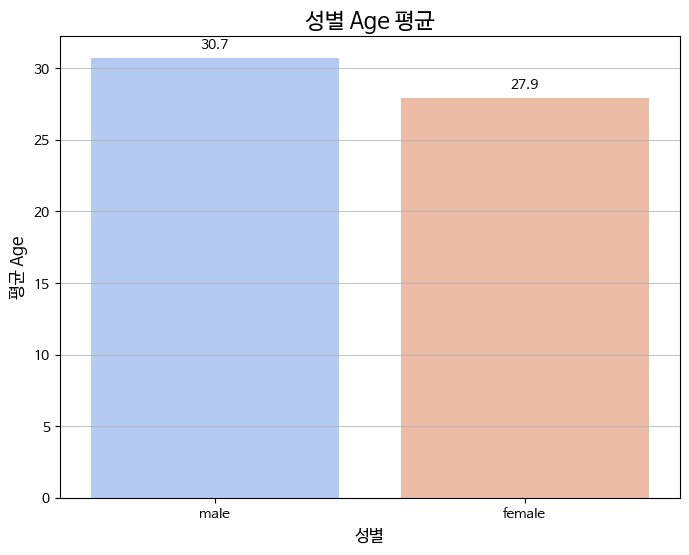

In [20]:
# Sex 변수에 따른 Age 평균 바 플롯
plt.figure(figsize=(8, 6))
barplot_age_sex = sns.barplot(data=titanic, x='sex', y='age', hue='sex',
                              errorbar=None, palette='coolwarm', legend=False)
plt.title('성별 Age 평균', fontsize=16)
plt.xlabel('성별', fontsize=12)
plt.ylabel('평균 Age', fontsize=12)
plt.grid(axis='y', alpha=0.75)

for p in barplot_age_sex.patches:
    barplot_age_sex.annotate(format(p.get_height(), '.1f'),
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points')
plt.show()

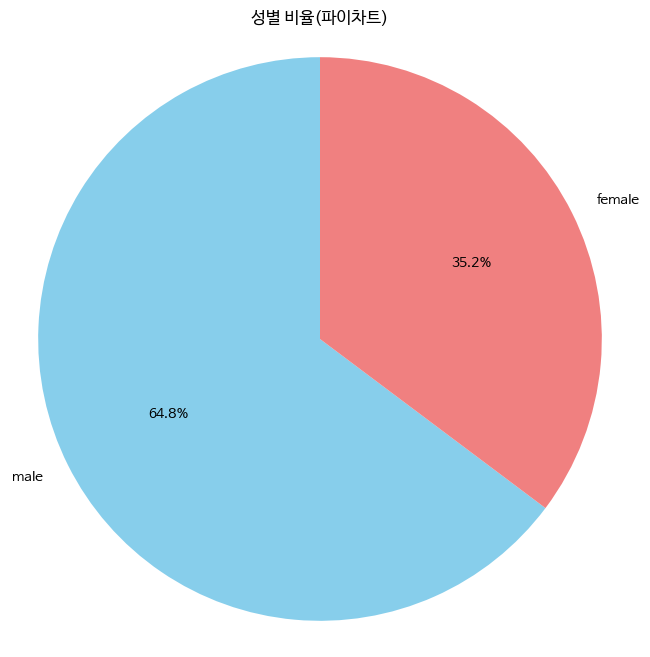

In [21]:
# 파이차트
plt.figure(figsize=(8, 8))
sex_counts = titanic["sex"].value_counts()
plt.pie(sex_counts, labels=sex_counts.index, autopct="%1.1f%%",
        startangle=90, colors=["skyblue", "lightcoral"])
plt.title("성별 비율(파이차트)")
plt.axis("equal") # 원형을 유지하도록 설정
plt.show()

# 2차시: 변수 간 관계 시각화

- 산점도 (Scatter Plot) + 회귀선 (regplot)
- Pairplot
- 그룹별 박스플롯
- 바이올린 플롯 (Violin Plot)
- 그룹별 막대그래프 (Grouped Bar Plot) — countplot+hue, stacked, normalized
- 히트맵 (Heatmap)


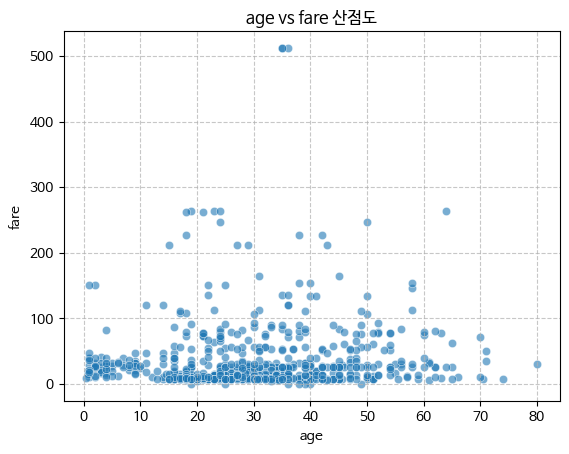

In [25]:
# age와 fare 변수의 기본 산점도
sns.scatterplot(data=titanic, x="age", y="fare", alpha=0.6)

plt.title("age vs fare 산점도")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

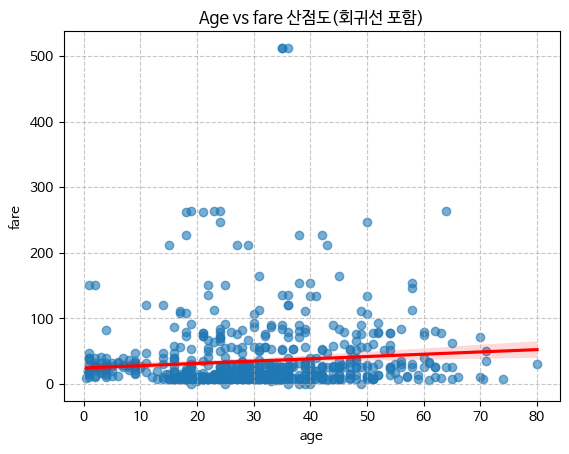

In [26]:
# 회귀선 추가
sns.regplot(data=titanic, x="age", y="fare",
            scatter_kws={"alpha": 0.6},
            line_kws={"color": "red"})
plt.title("Age vs fare 산점도(회귀선 포함)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

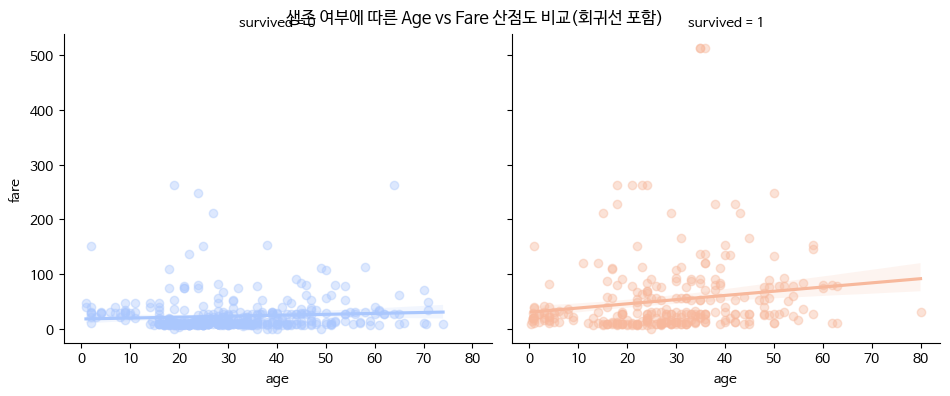

In [27]:
g = sns.lmplot(data=titanic, x="age", y="fare", hue="survived", col="survived",
               scatter_kws={"alpha": 0.4},
               height=4, aspect=1.2, palette="coolwarm")
g.fig.suptitle("생존 여부에 따른 Age vs Fare 산점도 비교(회귀선 포함)")
plt.show()

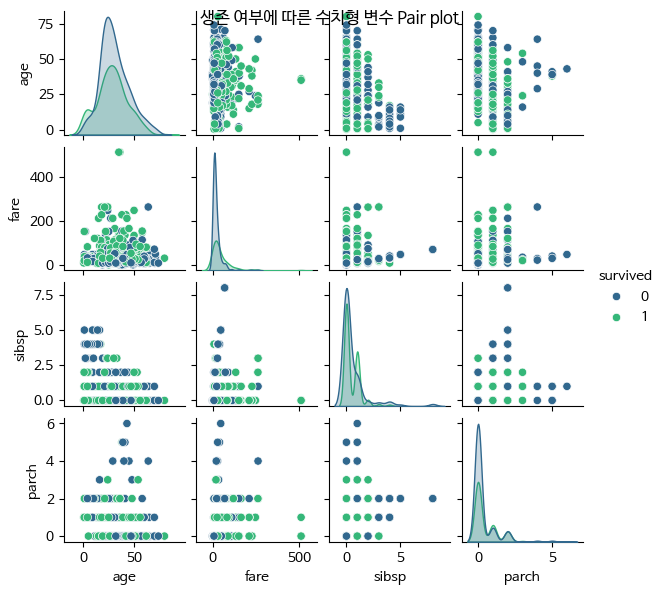

In [28]:
# 페어플롯
numerical_cols = ['age', 'fare', 'sibsp', 'parch'] # 수치형 변수 선택

g = sns.pairplot(titanic, vars=numerical_cols,
                 hue="survived", diag_kind="kde",
                 height=1.5, palette="viridis")
g.fig.suptitle("생존 여부에 따른 수치형 변수 Pair plot")
plt.show()

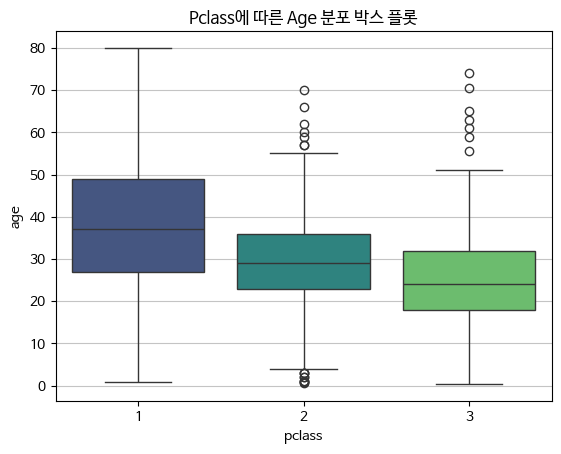

In [29]:
# 다변수 박스 플롯

# pclass에 따른 age 분포 박스 플롯
sns.boxplot(data=titanic, x="pclass", y="age", palette="viridis")
plt.title("Pclass에 따른 Age 분포 박스 플롯")
plt.grid(axis="y", alpha=0.75)
plt.show()

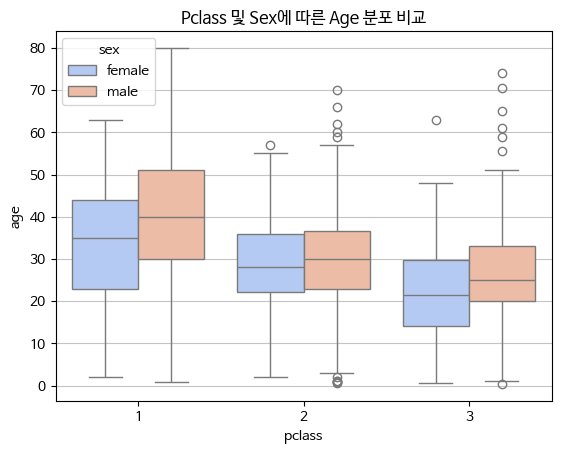

In [31]:
# Pclass와 Sex에 따른 Age 분포 박스 플롯(그룹화)
sns.boxplot(data=titanic, x="pclass", y="age", hue="sex", palette="coolwarm", legend=True)
plt.title("Pclass 및 Sex에 따른 Age 분포 비교")
plt.grid(axis="y", alpha=0.75)
plt.show()

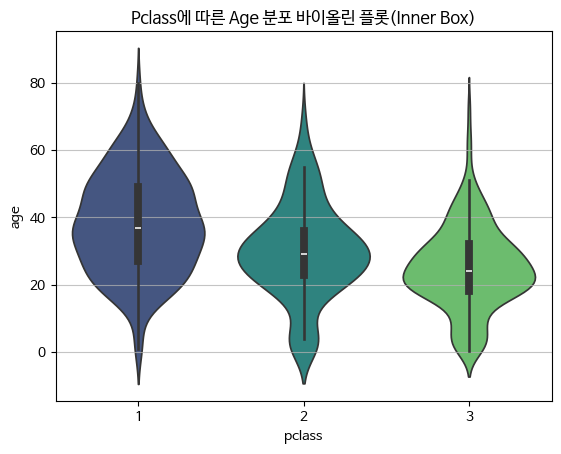

In [32]:
# 바이올린 플롯

# Pclass에 따른 Age 분포 바이올린 플롯
sns.violinplot(data=titanic, x="pclass", y="age", inner="box", palette="viridis")
plt.title("Pclass에 따른 Age 분포 바이올린 플롯(Inner Box)")
plt.grid(axis="y", alpha=0.75)
plt.show()

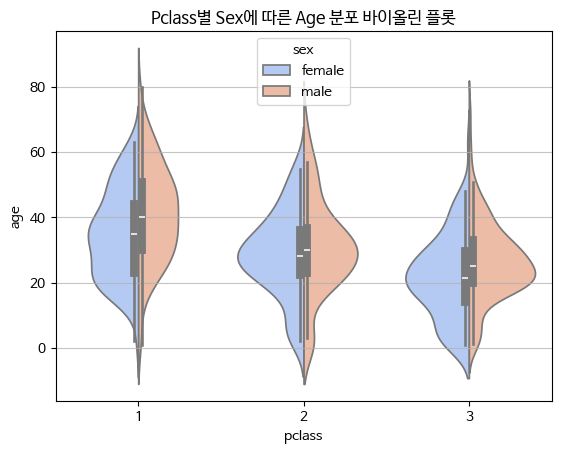

In [33]:
# Sex와 Pclass에 따른 Age 분포 바이올린 플롯
sns.violinplot(data=titanic, x="pclass", y="age", hue="sex", split=True,
               palette="coolwarm", legend=True)
plt.title("Pclass별 Sex에 따른 Age 분포 바이올린 플롯")
plt.grid(axis="y", alpha=0.75)
plt.show()

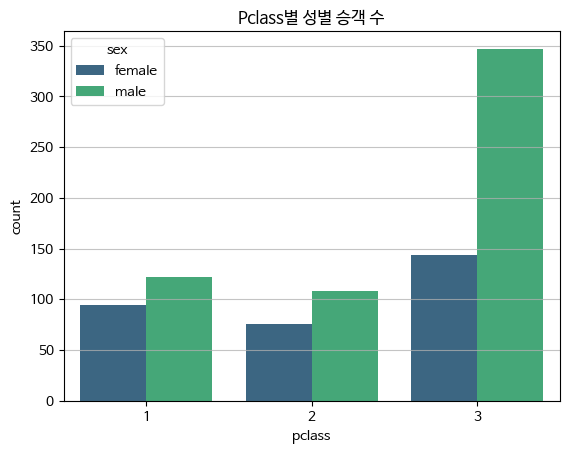

In [34]:
# 다차원 막대그래프

# Pclass와 Sex에 따른 승객 수를 비교하는 카운트 플롯
sns.countplot(data=titanic, x="pclass", hue="sex", palette="viridis", legend=True)
plt.title("Pclass별 성별 승객 수")
plt.grid(axis="y", alpha=0.75)
plt.show()

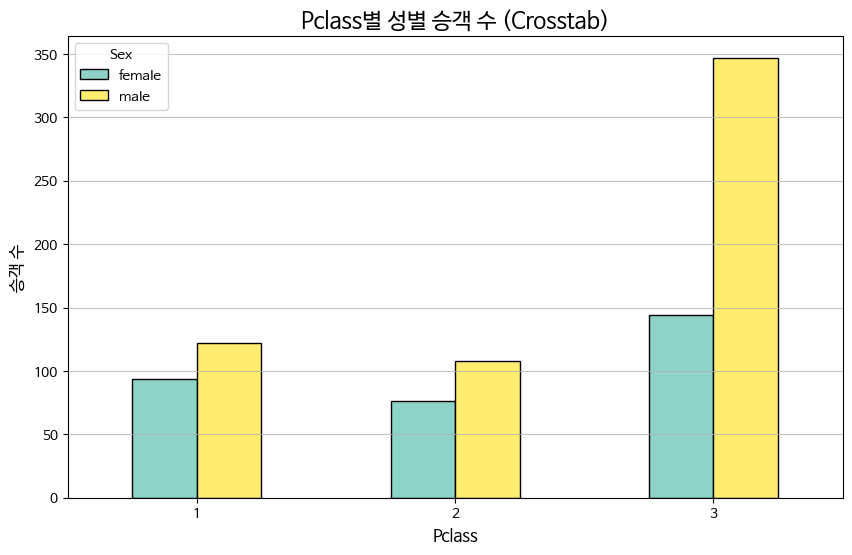

In [35]:
# Pclass와 Sex 간의 교차표 생성
crosstab_pclass_sex = pd.crosstab(titanic['pclass'], titanic['sex'])

# 교차표를 활용한 그룹화된 막대 그래프 (누적되지 않음)
ax = crosstab_pclass_sex.plot(kind='bar',
                              stacked=False,
                              figsize=(10, 6),
                              colormap='Set3', # Pastel1, Pastel2, Set3
                              edgecolor='black')

plt.title('Pclass별 성별 승객 수 (Crosstab)', fontsize=16)
plt.xlabel('Pclass', fontsize=12)
plt.ylabel('승객 수', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Sex')
plt.show()

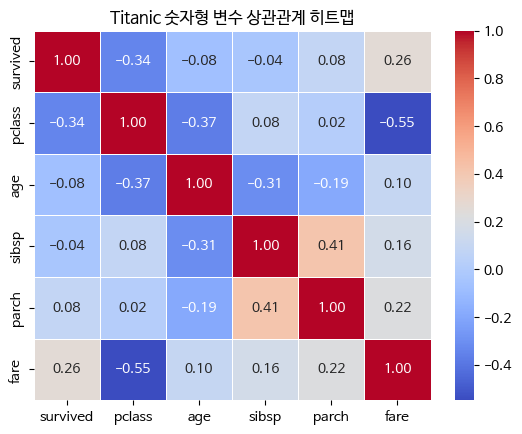

In [36]:
# 상관관계 히트맵

# 숫자형 변수 선택
numerical_titanic_df = titanic[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]

# 상관관계 행렬 계산
correlation_matrix = numerical_titanic_df.corr()

# 히트맵 그리기
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Titanic 숫자형 변수 상관관계 히트맵")
plt.show()

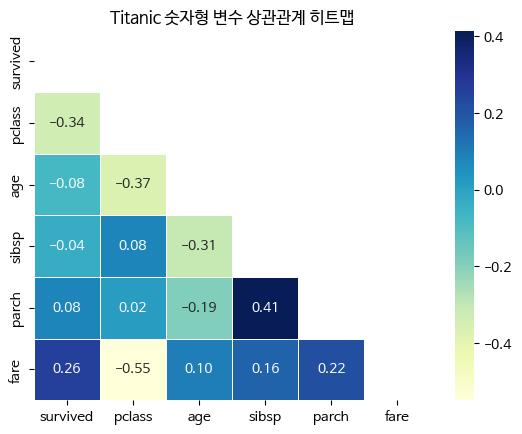

In [38]:
# 상삼각 마스크 생성
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 히트맵 그리기
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, mask=mask)
plt.title("Titanic 숫자형 변수 상관관계 히트맵")
plt.show()